# **Problem Statement**

## **Business Context**

Workplace safety in hazardous environments like construction sites and industrial plants is crucial to prevent accidents and injuries. One of the most important safety measures is ensuring workers wear safety helmets, which protect against head injuries from falling objects and machinery. Non-compliance with helmet regulations increases the risk of serious injuries or fatalities, making effective monitoring essential, especially in large-scale operations where manual oversight is prone to errors and inefficiency.

To overcome these challenges, SafeGuard Corp plans to develop an automated image analysis system capable of detecting whether workers are wearing safety helmets. This system will improve safety enforcement, ensuring compliance and reducing the risk of head injuries. By automating helmet monitoring, SafeGuard aims to enhance efficiency, scalability, and accuracy, ultimately fostering a safer work environment while minimizing human error in safety oversight.

## **Objective**

As a data scientist at SafeGuard Corp, you are tasked with developing an image classification model that classifies images into one of two categories:
- **With Helmet:** Workers wearing safety helmets.
- **Without Helmet:** Workers not wearing safety helmets.

## **Data Description**

The dataset consists of **631 images**, equally divided into two categories:

- **With Helmet:** 311 images showing workers wearing helmets.
- **Without Helmet:** 320 images showing workers not wearing helmets.

**Dataset Characteristics:**
- **Variations in Conditions:** Images include diverse environments such as construction sites, factories, and industrial settings, with variations in lighting, angles, and worker postures to simulate real-world conditions.
- **Worker Activities:** Workers are depicted in different actions such as standing, using tools, or moving, ensuring robust model learning for various scenarios.

# **Installing and Importing the Necessary Libraries**

In [1]:
# !pip install tensorflow[and-cuda] numpy==1.25.2 -q

In [2]:
# Import Tensorflow and check GPU access.
import tensorflow as tf
from tensorflow.python.client import device_lib
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print(tf.__version__)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("GPU Available: Yes")
    print("GPU Name: ", device_lib.list_local_devices()[-1].physical_device_desc)
else:
    print("GPU Available: No")

2025-10-04 18:24:18.353449: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-04 18:24:19.515126: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-04 18:24:46.061202: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Num GPUs Available: 1
2.20.0
GPU Available: Yes
GPU Name:  device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


I0000 00:00:1759620310.055091     801 gpu_device.cc:2020] Created device /device:GPU:0 with 3539 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [3]:
# Import required libraires
import os
import random
import numpy as np                                                                               
import pandas as pd
import seaborn as sns
import matplotlib.image as mpimg                                                                 
import matplotlib.pyplot as plt                                                                  
import math                                                                                      
import cv2
import time


# Tensorflow modules
import tensorflow as tf
import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator                              
from tensorflow.keras.models import Sequential                                                   
from tensorflow.keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D,BatchNormalization 
from tensorflow.keras.optimizers import Adam,SGD                                                 
from tensorflow.keras.models import Model
from keras.applications.vgg16 import VGG16      
from tensorflow.keras.applications.vgg16 import preprocess_input


#Imports functions for evaluating the performance of machine learning models
from sklearn import preprocessing    
from sklearn.model_selection import train_test_split  
from sklearn.metrics import confusion_matrix
from sklearn.metrics import mean_squared_error as mse           
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score, classification_report, roc_auc_score)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Set the seed using keras.utils.set_random_seed. This will set:
# 1) `numpy` seed
# 2) backend random seed
# 3) `python` random seed
tf.keras.utils.set_random_seed(812)

In [5]:
# measuring how long it takes to run this notebook.
start_time = time.time()

# **Data Overview**


## Loading the data

In [6]:
images = np.load('images_proj.npy')
labels = pd.read_csv('Labels_proj.csv')

In [7]:
# Check the shape of images and labels
print(images.shape)
print(labels.shape)

(631, 200, 200, 3)
(631, 1)


# **Exploratory Data Analysis**

### Plot random images from each of the classes and print their corresponding labels.

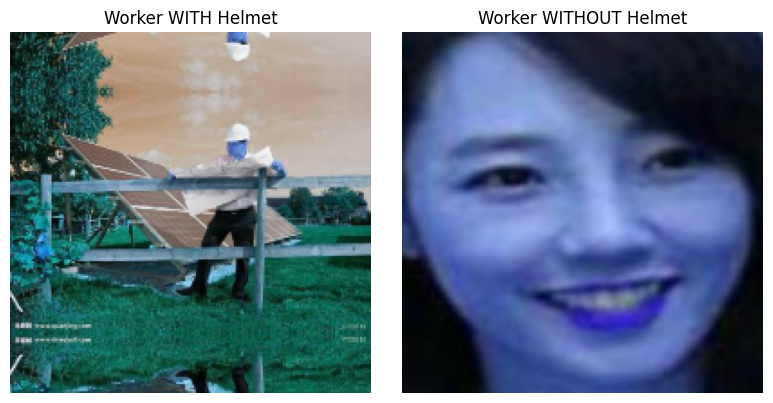

In [8]:
# separates data into classes
helmet_indices = np.where(labels == 1)[0]
no_helmet_indices = np.where(labels == 0)[0]  

# Select one image from each class
helmet_img = images[np.random.choice(helmet_indices)]
no_helmet_img = images[np.random.choice(no_helmet_indices)]

# Plot the images
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Display "With Helmet" image
axes[0].imshow(helmet_img)
axes[0].set_title("Worker WITH Helmet")
axes[0].axis('off')

# Display "Without Helmet" image
axes[1].imshow(no_helmet_img)
axes[1].set_title("Worker WITHOUT Helmet")
axes[1].axis('off')

# Show the plots
plt.tight_layout()
plt.show()

## Checking for class imbalance


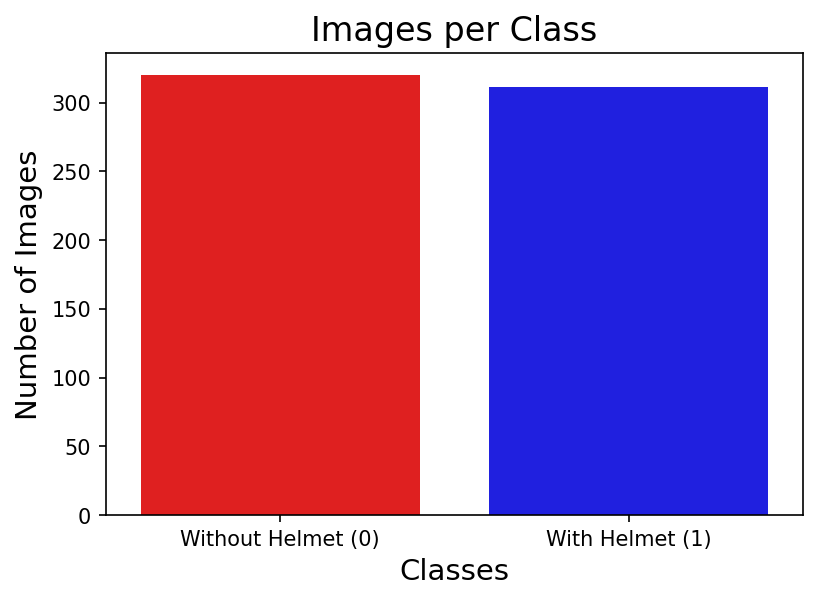

In [9]:
plt.figure(figsize=(6, 4), dpi=150)
sns.countplot(x=labels.iloc[:, 0], palette=['red', 'blue'])
plt.xlabel("Classes", fontsize=14)
plt.ylabel("Number of Images", fontsize=14)
plt.title("Images per Class", fontsize=16)
plt.xticks(ticks=[0, 1], labels=["Without Helmet (0)", "With Helmet (1)"]) ;

This is a a balanced dataset. While the number of images in each class is not exact, they are close. Each class has just over 300 images. 

# **Data Preprocessing**

## Converting images to grayscale

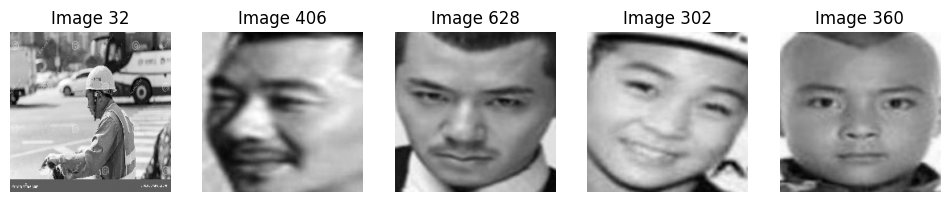

In [10]:
# Convert all images to grayscale to save data size. 
images_gray = [cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) for img in images]

# Display a random sample of grayscale images
num_samples = 5  # number of images to show
sample_indices = random.sample(range(len(images_gray)), num_samples)

plt.figure(figsize=(12, 6))
for i, idx in enumerate(sample_indices):
    plt.subplot(1, num_samples, i + 1)
    plt.imshow(images_gray[idx], cmap='gray')  # use gray colormap
    plt.axis("off")
    plt.title(f"Image {idx}")
plt.show()


In [11]:
# Checking to confirm that the images are now gray scale. Only height and width, no channels.
print(images[0].shape)        # original image
print(images_gray[0].shape)   # converted grayscale image

(200, 200, 3)
(200, 200)


## Split Dataset

In [12]:
X_train, X_temp, y_train, y_temp = train_test_split(np.array(images_gray),labels , test_size=0.24, random_state=42,stratify=labels)

In [13]:
X_val, X_test, y_val, y_test = train_test_split(X_temp,y_temp , test_size=0.5, random_state=42,stratify=y_temp)

In [14]:
images.shape

(631, 200, 200, 3)

In [15]:
X_train.shape

(479, 200, 200)

In [16]:
X_val.shape

(76, 200, 200)

In [17]:
X_test.shape

(76, 200, 200)

Checking the shape of the various data elements trying to decide on the appropriate split given the small size of the data set. This may be something that will need to be revisited depending on model performance. 

### Data Normalization

In [18]:
# Normalizing the data, between 0 and 1, to ensure there are no large numbers and to improve calculation speed.
X_train_normalized = X_train.astype('float32')/255.0
X_val_normalized = X_val.astype('float32')/255.0
X_test_normalized = X_test.astype('float32')/255.0

# **Model Building**

## Utility Functions

In [19]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors).reshape(-1)>0.5

    target = target.to_numpy().reshape(-1)


    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred, average='weighted')  # to compute Recall
    precision = precision_score(target, pred, average='weighted')  # to compute Precision
    f1 = f1_score(target, pred, average='weighted')  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame({"Accuracy": acc, "Recall": recall, "Precision": precision, "F1 Score": f1,},index=[0],)

    return df_perf

In [20]:
def plot_confusion_matrix(model,predictors,target,ml=False):
    """
    Function to plot the confusion matrix

    model: classifier
    predictors: independent variables
    target: dependent variable
    ml: To specify if the model used is an sklearn ML model or not (True means ML model)
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors).reshape(-1)>0.5

    target = target.to_numpy().reshape(-1)

    # Plotting the Confusion Matrix using confusion matrix() function which is also predefined tensorflow module
    confusion_matrix = tf.math.confusion_matrix(target,pred)
    f, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        confusion_matrix,
        annot=True,
        linewidths=.4,
        fmt="d",
        square=True,
        ax=ax
    )
    plt.show()

## Model 1: Simple Convolutional Neural Network (CNN)

In [21]:
# Initializing Model
model_1 = Sequential()

# Feature extraction = Convolutional and pooling layers
model_1.add(Conv2D(32, (3, 3), activation='relu', padding="same", input_shape=(200,200,1))) 
model_1.add(MaxPooling2D((4, 4), padding='same'))
model_1.add(Conv2D(16, (3, 3), activation='relu', padding="same")) 
model_1.add(MaxPooling2D((4,4), padding='same')) 
model_1.add(Conv2D(8, (3,3), activation='relu', padding="same")) 
model_1.add(MaxPooling2D((4,4), padding='same')) 

# Flatten and Dense layers
model_1.add(Flatten())
model_1.add(Dense(8, activation='relu'))
model_1.add(Dense(4, activation='relu'))
model_1.add(Dense(1, activation='sigmoid'))  #Using the Sigmoid activation function sine this is binary classification 

# Compile the Model with Adam Optimizer
model_1.compile(optimizer='Adam', loss='binary_crossentropy', metrics=["accuracy", "Precision"]) 

# Summary of the model parameters
model_1.summary()

I0000 00:00:1759620313.521977     801 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3539 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 200, 200, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 50, 50, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 13, 13, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │         1,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,177 (28.04 KB)

 Trainable params: 7,177 (28.04 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# To determine input size
images_gray[0].shape

(200, 200)

In [23]:
history_1 = model_1.fit(
            X_train_normalized, y_train,
            epochs=15, 
            validation_data=(X_val_normalized,y_val),
            shuffle=True,
            batch_size=20, 
            verbose=2
)

Epoch 1/15


2025-10-04 18:25:16.060772: I external/local_xla/xla/service/service.cc:163] XLA service 0x78a930004870 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-10-04 18:25:16.060801: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2025-10-04 18:25:16.158031: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-10-04 18:25:16.460286: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91301
I0000 00:00:1759620319.872439    1206 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


24/24 - 9s - 386ms/step - Precision: 0.8837 - accuracy: 0.5762 - loss: 0.6920 - val_Precision: 1.0000 - val_accuracy: 0.6053 - val_loss: 0.6881
Epoch 2/15
24/24 - 3s - 105ms/step - Precision: 1.0000 - accuracy: 0.6639 - loss: 0.6762 - val_Precision: 1.0000 - val_accuracy: 0.6579 - val_loss: 0.6479
Epoch 3/15
24/24 - 0s - 14ms/step - Precision: 1.0000 - accuracy: 0.7683 - loss: 0.5904 - val_Precision: 1.0000 - val_accuracy: 0.7368 - val_loss: 0.5156
Epoch 4/15
24/24 - 0s - 13ms/step - Precision: 1.0000 - accuracy: 0.8998 - loss: 0.4592 - val_Precision: 1.0000 - val_accuracy: 0.9605 - val_loss: 0.4264
Epoch 5/15
24/24 - 0s - 13ms/step - Precision: 1.0000 - accuracy: 0.9603 - loss: 0.3709 - val_Precision: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.3990
Epoch 6/15
24/24 - 0s - 14ms/step - Precision: 1.0000 - accuracy: 0.9812 - loss: 0.3461 - val_Precision: 1.0000 - val_accuracy: 0.9737 - val_loss: 0.3439
Epoch 7/15
24/24 - 0s - 14ms/step - Precision: 1.0000 - accuracy: 0.9896 - loss: 0.32

### Vizualizing the predictions

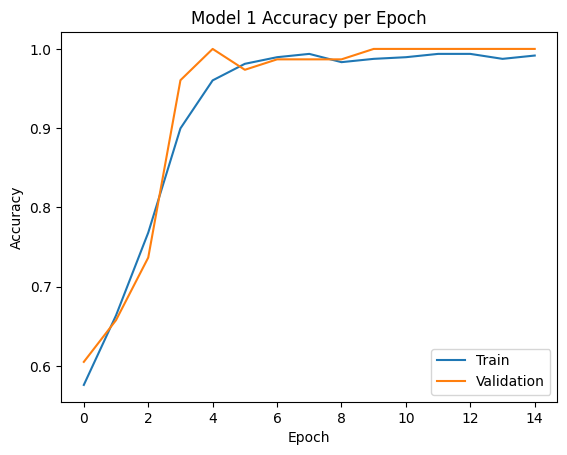

In [24]:
plt.plot(history_1.history['accuracy']) 
plt.plot(history_1.history['val_accuracy']) 
plt.title('Model 1 Accuracy per Epoch') 
plt.ylabel('Accuracy') 
plt.xlabel('Epoch') 
plt.legend(['Train', 'Validation'], loc='lower right')
plt.show()

In [25]:
model_1_train_perf = model_performance_classification(model_1, X_train_normalized,y_train)

print("Train performance metrics")
print(model_1_train_perf)

15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.995825  0.995825    0.99586  0.995825


In [26]:
model_1_valid_perf = model_performance_classification(model_1, X_val_normalized,y_val)

print("Validation performance metrics")
print(model_1_valid_perf)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 334ms/step
Validation performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


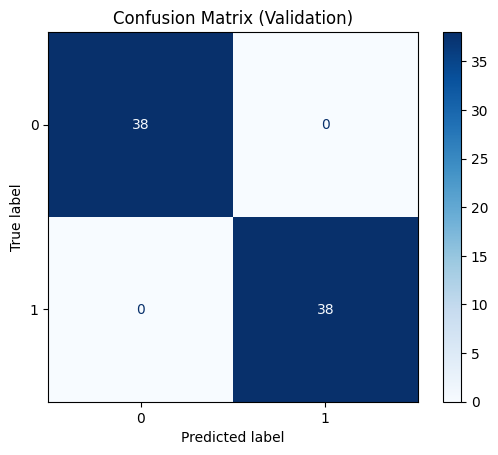

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0

Classification Report:
               precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        38
           1     1.0000    1.0000    1.0000        38

    accuracy                         1.0000        76
   macro avg     1.0000    1.0000    1.0000        76
weighted avg     1.0000    1.0000    1.0000        76

ROC AUC  : 1.0


In [27]:

y_prob = model_1.predict(X_val_normalized, verbose=0).ravel()   # shape (n,)
y_true = np.asarray(y_val).ravel()
y_pred = (y_prob >= 0.5).astype(int)

# Create Confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Validation)")
plt.show()

# 5) Metrics
print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, zero_division=0))
print("Recall   :", recall_score(y_true, y_pred, zero_division=0))
print("F1-score :", f1_score(y_true, y_pred, zero_division=0))
print("\nClassification Report:\n", classification_report(y_true, y_pred, digits=4))

# Optional: ROC AUC (works with probabilities)
try:
    print("ROC AUC  :", roc_auc_score(y_true, y_prob))
except ValueError:
    pass


The standard CNN worked extremely well even with a limited number images. Did it perform too well will need to check against test data to verify. 

## Model 2: (VGG-16 (Base))

In [28]:
# Importing and using the convolution, feature extraction layer of th VGG-16 model.
vgg_model = VGG16(weights='imagenet',include_top=False,input_shape=(200, 200, 3))
vgg_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 200, 200, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 200, 200, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 100, 100, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 100, 100, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 100, 100, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 50, 50, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 50, 50, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 25, 25, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 25, 25, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 12, 12, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 6, 6, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
# Freeze VGG-16 layers so they don't pick up training
for layer in vgg_model.layers:
    layer.trainable = False

### Create Model 2

In [30]:
model_2 = Sequential()
model_2.add(vgg_model)
model_2.add(Flatten())
model_2.add(Dense(1, activation='sigmoid'))
model_2.compile(optimizer='Adam', loss=keras.losses.BinaryCrossentropy(), metrics=["accuracy", "Precision"])
model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │        18,433 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,733,121 (56.20 MB)

 Trainable params: 18,433 (72.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [31]:
train_datagen = ImageDataGenerator(preprocessing_function=lambda x: preprocess_input(x * 255.0))

In [32]:
# Fitting the model
batch_size = 20

# Make 3-channel inputs (N, H, W, 3)
X_train_3ch = np.repeat(X_train_normalized[..., None].astype('float32'), 3, axis=-1)
X_val_3ch   = np.repeat(X_val_normalized[..., None].astype('float32'),   3, axis=-1)

history_2 = model_2.fit(
    train_datagen.flow(X_train_3ch, y_train, batch_size=batch_size, seed=42, shuffle=True),
    epochs=25,
    steps_per_epoch=math.ceil(X_train_3ch.shape[0] / batch_size),  # or omit; Keras can infer
    validation_data=(X_val_3ch, y_val),
    verbose=2
)


Epoch 1/25


2025-10-04 18:25:36.787321: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.66GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-10-04 18:25:45.056929: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.63GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-10-04 18:25:52.935681: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 3.04GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


24/24 - 29s - 1s/step - Precision: 0.9461 - accuracy: 0.9562 - loss: 0.2390 - val_Precision: 1.0000 - val_accuracy: 0.9868 - val_loss: 0.2201
Epoch 2/25
24/24 - 2s - 79ms/step - Precision: 1.0000 - accuracy: 1.0000 - loss: 2.6811e-10 - val_Precision: 1.0000 - val_accuracy: 0.9868 - val_loss: 0.1931
Epoch 3/25
24/24 - 2s - 77ms/step - Precision: 1.0000 - accuracy: 1.0000 - loss: 9.5303e-11 - val_Precision: 1.0000 - val_accuracy: 0.9868 - val_loss: 0.1909
Epoch 4/25
24/24 - 2s - 104ms/step - Precision: 1.0000 - accuracy: 1.0000 - loss: 8.0648e-11 - val_Precision: 1.0000 - val_accuracy: 0.9868 - val_loss: 0.1907
Epoch 5/25
24/24 - 2s - 80ms/step - Precision: 1.0000 - accuracy: 1.0000 - loss: 7.0348e-11 - val_Precision: 1.0000 - val_accuracy: 0.9868 - val_loss: 0.1907
Epoch 6/25
24/24 - 2s - 78ms/step - Precision: 1.0000 - accuracy: 1.0000 - loss: 6.4867e-11 - val_Precision: 1.0000 - val_accuracy: 0.9868 - val_loss: 0.1907
Epoch 7/25
24/24 - 2s - 80ms/step - Precision: 1.0000 - accuracy: 1

### Visualizing the prediction:

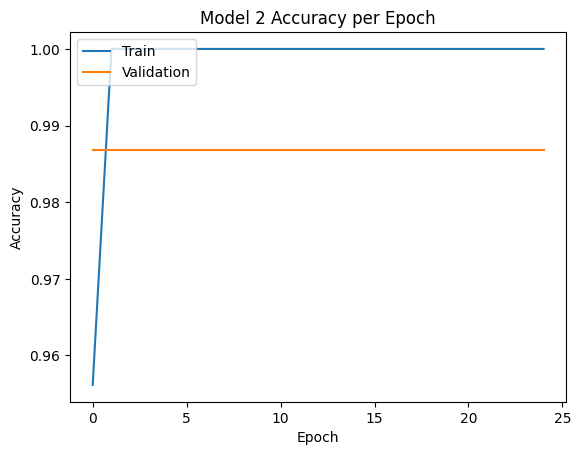

In [33]:
plt.plot(history_2.history['accuracy']) #Complete the code to plot the train metrics
plt.plot(history_2.history['val_accuracy']) #Complete the code to plot the validation data metrics
plt.title('Model 2 Accuracy per Epoch') #Complete the code to define the title for the plot
plt.ylabel('Accuracy') #Complete the code to define the label for the y-axis
plt.xlabel('Epoch') #Complete the code to define the label for the x-axis
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [34]:
model_2_train_perf = model_performance_classification(model_2, X_train_3ch,y_train)

print("Train performance metrics")
print(model_2_train_perf)

14/15 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step

2025-10-04 18:26:56.114539: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 3.01GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-10-04 18:26:58.614438: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.54GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 732ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.993737  0.993737   0.993745  0.993737


In [35]:
model_2_valid_perf = model_performance_classification(model_2, X_val_3ch,y_val)

print("Validation performance metrics")
print(model_2_valid_perf)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 234ms/step
Validation performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.986842  0.986842   0.987179   0.98684


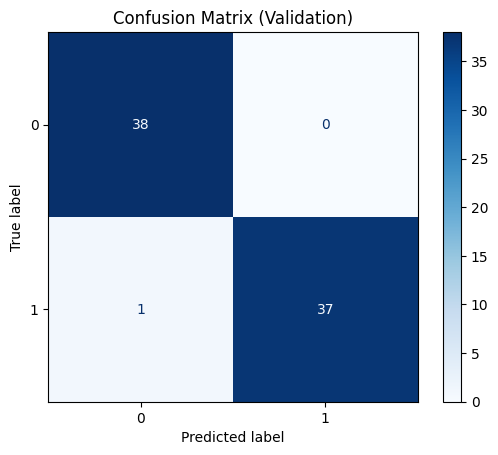

Accuracy : 0.9868421052631579
Precision: 1.0
Recall   : 0.9736842105263158
F1-score : 0.9866666666666667

Classification Report:
               precision    recall  f1-score   support

           0     0.9744    1.0000    0.9870        38
           1     1.0000    0.9737    0.9867        38

    accuracy                         0.9868        76
   macro avg     0.9872    0.9868    0.9868        76
weighted avg     0.9872    0.9868    0.9868        76

ROC AUC  : 0.9986149584487535


In [36]:

y_prob = model_2.predict(X_val_3ch, verbose=0).ravel()   # shape (n,)
y_true = np.asarray(y_val).ravel()
y_pred = (y_prob >= 0.5).astype(int)

# Create Confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Validation)")
plt.show()

# 5) Metrics
print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, zero_division=0))
print("Recall   :", recall_score(y_true, y_pred, zero_division=0))
print("F1-score :", f1_score(y_true, y_pred, zero_division=0))
print("\nClassification Report:\n", classification_report(y_true, y_pred, digits=4))

# Optional: ROC AUC (works with probabilities)
try:
    print("ROC AUC  :", roc_auc_score(y_true, y_prob))
except ValueError:
    pass


Model 2, VGG-16 Base, did poorly. This is undestandable, just the convoultion layer with no prediction layer just doesn't seem like it is a good iead. 

## Model 3: (VGG-16 (Base + FFNN))

### Create Model 3

In [37]:
model_3 = Sequential()

# Feature Extraction 
model_3.add(vgg_model)
model_3.add(Flatten())

# Prediction
model_3.add(Dense(32,activation='relu')) 
model_3.add(Dropout(rate=0.5))
model_3.add(Dense(16,activation='relu')) 
model_3.add(Dropout(rate=0.5))

# Output Layer
model_3.add(Dense(1, activation='sigmoid')) 

opt = Adam(learning_rate=0.5) 

model_3.compile(optimizer='Adam',loss=keras.losses.BinaryCrossentropy(), metrics=["accuracy", "Precision"])
model_3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │       589,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,305,089 (58.38 MB)

 Trainable params: 590,401 (2.25 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [38]:
batch_size = 20

# Make 3-channel inputs (N, H, W, 3)
X_train_3ch = np.repeat(X_train_normalized[..., None].astype('float32'), 3, axis=-1)
X_val_3ch   = np.repeat(X_val_normalized[..., None].astype('float32'),   3, axis=-1)

history_3 = model_3.fit(
    train_datagen.flow(X_train_3ch, y_train, batch_size=batch_size, seed=42, shuffle=True),
    epochs=25,
    steps_per_epoch=math.ceil(X_train_3ch.shape[0] / batch_size),  # or omit; Keras can infer
    validation_data=(X_val_3ch, y_val),
    verbose=2
)


Epoch 1/25
24/24 - 8s - 320ms/step - Precision: 0.8652 - accuracy: 0.8580 - loss: 1.1663 - val_Precision: 0.6441 - val_accuracy: 0.7237 - val_loss: 0.4224
Epoch 2/25
24/24 - 2s - 80ms/step - Precision: 0.9386 - accuracy: 0.9248 - loss: 0.6346 - val_Precision: 0.5067 - val_accuracy: 0.5132 - val_loss: 0.7555
Epoch 3/25
24/24 - 2s - 79ms/step - Precision: 0.9348 - accuracy: 0.9248 - loss: 0.7748 - val_Precision: 0.5507 - val_accuracy: 0.5921 - val_loss: 0.6490
Epoch 4/25
24/24 - 2s - 75ms/step - Precision: 0.9583 - accuracy: 0.9666 - loss: 0.2467 - val_Precision: 0.6552 - val_accuracy: 0.7368 - val_loss: 0.4267
Epoch 5/25
24/24 - 2s - 75ms/step - Precision: 0.9303 - accuracy: 0.9457 - loss: 0.2712 - val_Precision: 0.7600 - val_accuracy: 0.8421 - val_loss: 0.3684
Epoch 6/25
24/24 - 2s - 75ms/step - Precision: 0.9370 - accuracy: 0.9415 - loss: 0.3119 - val_Precision: 1.0000 - val_accuracy: 0.9868 - val_loss: 0.3148
Epoch 7/25
24/24 - 3s - 114ms/step - Precision: 0.9485 - accuracy: 0.9436 -

#### Visualizing the predictions

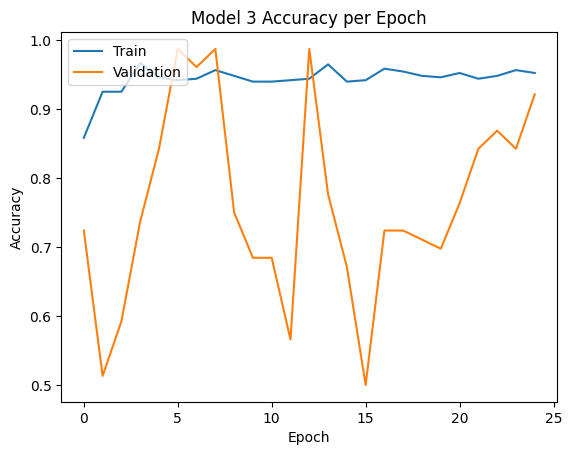

In [39]:
plt.plot(history_3.history['accuracy'])
plt.plot(history_3.history['val_accuracy'])
plt.title('Model 3 Accuracy per Epoch')
plt.ylabel('Accuracy')
plt.xlabel('Epoch') 
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [40]:
model_3_train_perf = model_performance_classification(model_3, X_train_3ch,y_train)

print("Train performance metrics")
print(model_3_train_perf)

15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 143ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.960334  0.960334    0.96329  0.960295


In [41]:
model_3_valid_perf = model_performance_classification(model_3, X_val_3ch,y_val)

print("Validation performance metrics")
print(model_3_valid_perf)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 379ms/step
Validation performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.921053  0.921053    0.92577  0.920833


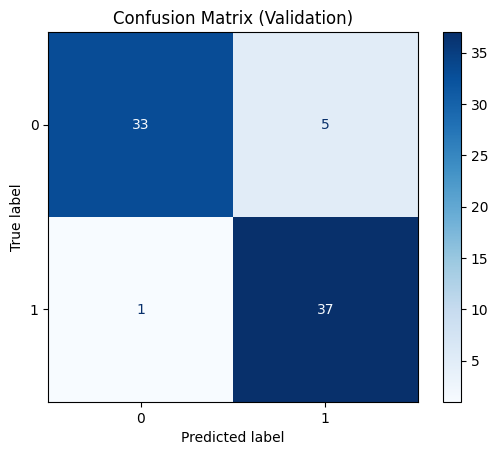

Accuracy : 0.9210526315789473
Precision: 0.8809523809523809
Recall   : 0.9736842105263158
F1-score : 0.925

Classification Report:
               precision    recall  f1-score   support

           0     0.9706    0.8684    0.9167        38
           1     0.8810    0.9737    0.9250        38

    accuracy                         0.9211        76
   macro avg     0.9258    0.9211    0.9208        76
weighted avg     0.9258    0.9211    0.9208        76

ROC AUC  : 0.9958448753462603


In [42]:

y_prob = model_3.predict(X_val_3ch, verbose=0).ravel()   # shape (n,)
y_true = np.asarray(y_val).ravel()
y_pred = (y_prob >= 0.5).astype(int)

# Create Confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Validation)")
plt.show()

# 5) Metrics
print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, zero_division=0))
print("Recall   :", recall_score(y_true, y_pred, zero_division=0))
print("F1-score :", f1_score(y_true, y_pred, zero_division=0))
print("\nClassification Report:\n", classification_report(y_true, y_pred, digits=4))

# Optional: ROC AUC (works with probabilities)
try:
    print("ROC AUC  :", roc_auc_score(y_true, y_prob))
except ValueError:
    pass


In [43]:
model_3_train_perf = model_performance_classification(model_3, X_train_3ch,y_train)

print("Train performance metrics")
print(model_3_train_perf)

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.960334  0.960334    0.96329  0.960295


Model 3, VGG-16 Base to FFNN, might have actually done worse that than VGG-16 Base. Perhaps not enough immages for the CNN to learn the dataset? Regardless the standard CNN still significatly out performed this model.

## Model 4: (VGG-16 (Base + FFNN + Data Augmentation)

- In most of the real-world case studies, it is challenging to acquire a large number of images and then train CNNs.
- To overcome this problem, one approach we might consider is **Data Augmentation**.
- CNNs have the property of **translational invariance**, which means they can recognise an object even if its appearance shifts translationally in some way. - Taking this attribute into account, we can augment the images using the techniques listed below

    -  Horizontal Flip (should be set to True/False)
    -  Vertical Flip (should be set to True/False)
    -  Height Shift (should be between 0 and 1)
    -  Width Shift (should be between 0 and 1)
    -  Rotation (should be between 0 and 180)
    -  Shear (should be between 0 and 1)
    -  Zoom (should be between 0 and 1) etc.

Remember, **data augmentation should not be used in the validation/test data set**.

In [44]:
model_4 = Sequential()

# Feature Extraction 
model_4.add(vgg_model)
model_4.add(Flatten())

# Prediction
model_4.add(Dense(32,activation='relu')) 
model_4.add(Dropout(rate=0.5))
model_4.add(Dense(16,activation='relu')) 
model_4.add(Dropout(rate=0.5))

# Output Layer
model_4.add(Dense(1, activation='sigmoid')) 

opt = Adam(learning_rate=0.5) 

model_4.compile(optimizer='Adam',loss=keras.losses.BinaryCrossentropy(), metrics=["accuracy", "Precision"])
model_4.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │       589,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,305,089 (58.38 MB)

 Trainable params: 590,401 (2.25 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [45]:
train_datagen = ImageDataGenerator(
                              rotation_range=0.5, 
                              fill_mode='nearest',width_shift_range=0.5,height_shift_range=0.5,shear_range=0.5,zoom_range=0.5
                              )

In [46]:
batch_size = 20

# Make 3-channel inputs (N, H, W, 3)
X_train_3ch = np.repeat(X_train_normalized[..., None].astype('float32'), 3, axis=-1)
X_val_3ch   = np.repeat(X_val_normalized[..., None].astype('float32'),   3, axis=-1)

history_4 = model_4.fit(
    train_datagen.flow(X_train_3ch, y_train, batch_size=batch_size, seed=42, shuffle=True),
    epochs=25,
    steps_per_epoch=math.ceil(X_train_3ch.shape[0] / batch_size),  # or omit; Keras can infer
    validation_data=(X_val_3ch, y_val),
    verbose=2
)

Epoch 1/25
24/24 - 8s - 347ms/step - Precision: 0.6186 - accuracy: 0.6138 - loss: 0.6928 - val_Precision: 0.9744 - val_accuracy: 0.9868 - val_loss: 0.2117
Epoch 2/25
24/24 - 2s - 97ms/step - Precision: 0.7788 - accuracy: 0.7495 - loss: 0.4421 - val_Precision: 0.9744 - val_accuracy: 0.9868 - val_loss: 0.1596
Epoch 3/25
24/24 - 3s - 106ms/step - Precision: 0.8571 - accuracy: 0.7891 - loss: 0.3880 - val_Precision: 0.9744 - val_accuracy: 0.9868 - val_loss: 0.0987
Epoch 4/25
24/24 - 2s - 102ms/step - Precision: 0.8653 - accuracy: 0.8017 - loss: 0.3428 - val_Precision: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0500
Epoch 5/25
24/24 - 2s - 101ms/step - Precision: 0.8969 - accuracy: 0.8288 - loss: 0.3245 - val_Precision: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0282
Epoch 6/25
24/24 - 2s - 99ms/step - Precision: 0.8636 - accuracy: 0.8079 - loss: 0.3274 - val_Precision: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0299
Epoch 7/25
24/24 - 2s - 103ms/step - Precision: 0.9140 - accuracy: 0.828

#### Visualizing the predictions

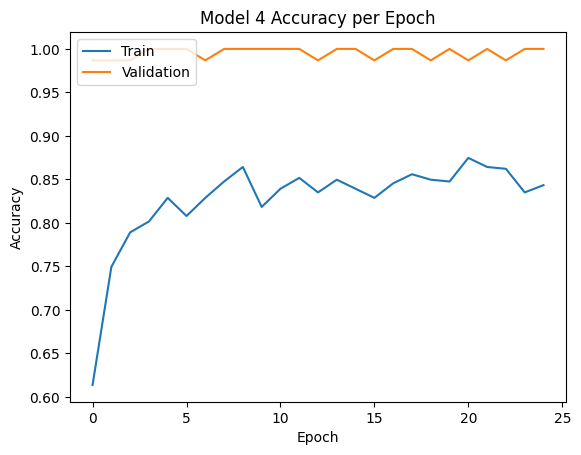

In [47]:
plt.plot(history_4.history['accuracy'])
plt.plot(history_4.history['val_accuracy'])
plt.title('Model 4 Accuracy per Epoch')
plt.ylabel('Accuracy')
plt.xlabel('Epoch') 
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [48]:
model_4_train_perf = model_performance_classification(model_4, X_train_3ch,y_train)

print("Train performance metrics")
print(model_4_train_perf)

15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 132ms/step
Train performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


In [49]:
model_4_valid_perf = model_performance_classification(model_4, X_val_3ch,y_val)

print("Validation performance metrics")
print(model_4_valid_perf)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 361ms/step
Validation performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0


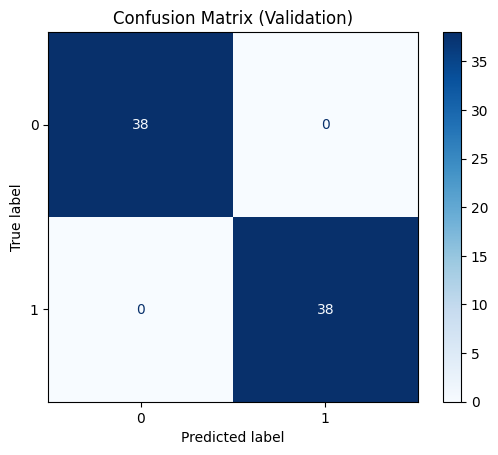

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0

Classification Report:
               precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        38
           1     1.0000    1.0000    1.0000        38

    accuracy                         1.0000        76
   macro avg     1.0000    1.0000    1.0000        76
weighted avg     1.0000    1.0000    1.0000        76

ROC AUC  : 1.0


In [50]:

y_prob = model_4.predict(X_val_3ch, verbose=0).ravel()   # shape (n,)
y_true = np.asarray(y_val).ravel()
y_pred = (y_prob >= 0.5).astype(int)

# Create Confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Validation)")
plt.show()

# 5) Metrics
print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, zero_division=0))
print("Recall   :", recall_score(y_true, y_pred, zero_division=0))
print("F1-score :", f1_score(y_true, y_pred, zero_division=0))
print("\nClassification Report:\n", classification_report(y_true, y_pred, digits=4))

# Optional: ROC AUC (works with probabilities)
try:
    print("ROC AUC  :", roc_auc_score(y_true, y_prob))
except ValueError:
    pass


# **Model Performance Comparison and Final Model Selection**

In [51]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        model_1_train_perf.T,
        model_2_train_perf.T,
        model_3_train_perf.T,
        model_4_train_perf.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Simple Convolutional Neural Network (CNN)","VGG-16 (Base)","VGG-16 (Base+FFNN)","VGG-16 (Base+FFNN+Data Aug)"
]

In [52]:
models_valid_comp_df = pd.concat(
    [
        model_1_valid_perf.T,
        model_2_valid_perf.T,
        model_3_valid_perf.T,
        model_4_valid_perf.T

    ],
    axis=1,
)
models_valid_comp_df.columns = [
 "Simple Convolutional Neural Network (CNN)","VGG-16 (Base)","VGG-16 (Base+FFNN)","VGG-16 (Base+FFNN+Data Aug)"
]

In [53]:
models_train_comp_df

,Simple Convolutional Neural Network (CNN),VGG-16 (Base),VGG-16 (Base+FFNN),VGG-16 (Base+FFNN+Data Aug)
Accuracy,0.995825,0.993737,0.960334,1.0
Recall,0.995825,0.993737,0.960334,1.0
Precision,0.995860,0.993745,0.963290,1.0
F1 Score,0.995825,0.993737,0.960295,1.0


In [54]:
models_valid_comp_df

,Simple Convolutional Neural Network (CNN),VGG-16 (Base),VGG-16 (Base+FFNN),VGG-16 (Base+FFNN+Data Aug)
Accuracy,1.0,0.986842,0.921053,1.0
Recall,1.0,0.986842,0.921053,1.0
Precision,1.0,0.987179,0.925770,1.0
F1 Score,1.0,0.986840,0.920833,1.0


In [55]:
models_train_comp_df - models_valid_comp_df

,Simple Convolutional Neural Network (CNN),VGG-16 (Base),VGG-16 (Base+FFNN),VGG-16 (Base+FFNN+Data Aug)
Accuracy,-0.004175,0.006895,0.039281,0.0
Recall,-0.004175,0.006895,0.039281,0.0
Precision,-0.004140,0.006566,0.037519,0.0
F1 Score,-0.004175,0.006897,0.039461,0.0


## Test Performance - VGG-16(Base + FFNN + Data Augmentation)

In [56]:
X_test_normalized.shape

(76, 200, 200)

In [57]:
# X_test_4d = np.expand_dims(X_test_normalized.astype('float32'), axis=-1)
X_test_3ch = np.repeat(X_test_normalized[..., None].astype('float32'), 3, axis=-1)

In [58]:
model_test_perf = model_performance_classification(model_4, X_test_3ch,y_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


In [59]:
model_test_perf

,Accuracy,Recall,Precision,F1 Score
0,1.0,1.0,1.0,1.0


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


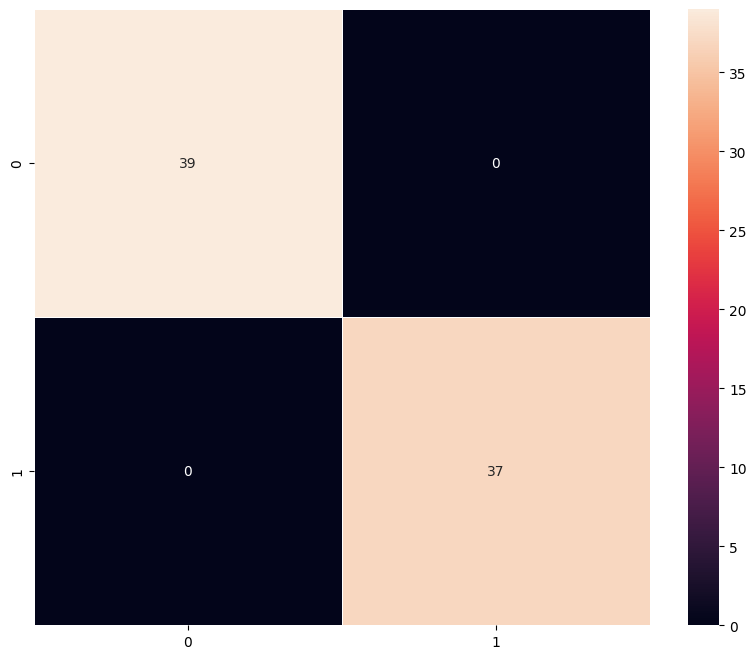

In [60]:
plot_confusion_matrix(model_4, X_test_3ch,y_test) 

## Test Performance - Simple CNN

In [61]:
model_test_perf = model_performance_classification(model_1, X_test_normalized,y_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [62]:
model_test_perf

,Accuracy,Recall,Precision,F1 Score
0,1.0,1.0,1.0,1.0


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


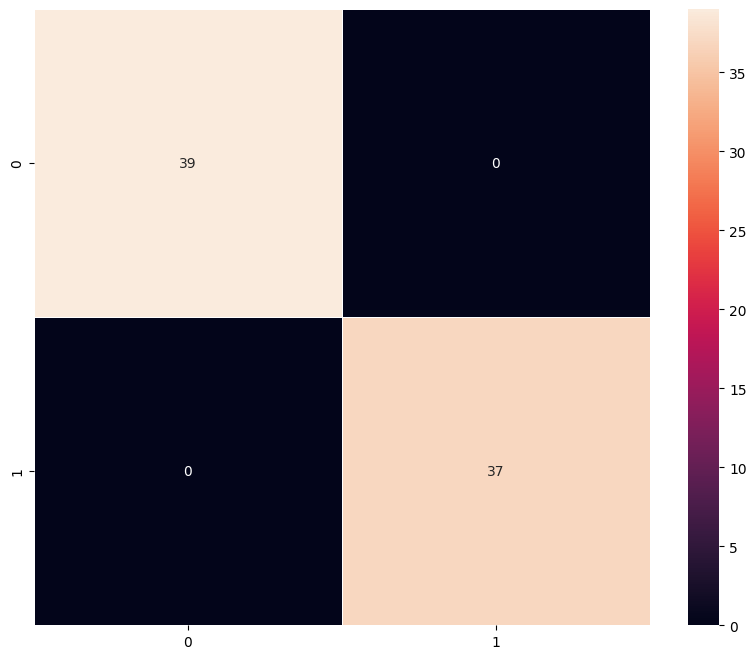

In [63]:
plot_confusion_matrix(model_1, X_test_normalized,y_test)

# Model Selection

Of the four models we developed in this notebook the Simple Convolutional Neural Network and the VGG-16 Fully Loaded (Base + FFNN + Data Augmentation) are a tie. I think simplier is better, since performance is equal, and I am going to select the Simple CNN. The simplier model will be easier to develop and deploy. The pipelines supporting it will also be less complex, faster and, less resource intensive. 

Other Models, the VGG-16 Base and VGG-16 Bae + FFNN did wirse than poorly. It is like they could not learn. I under this for the base model that was just a convolution feature extractor. Regardless these two models did not make the cut. 
    

# **Actionable Insights & Recommendations**

- Model selected - simple/standard CNN. Simplier is better. 
- Model deployment 
  - Successfully deployed this model will provide a safer work environment for affected employees
  - It is recommended that a app with a supporting pipeline be developed in Streamlit, Flask, or Django, to take feeds from cameras - fixed or drones, that provide input data to the model to identify employees not wearing their hardhats. This information could then be forawrded to supervisors for corrective action.
  - Depending on the work site the model could be trained to look for other personal protective equipment as required.
  - Continue collecting data and training the model on larger datasets to ensure functionality and relevance are maintained. 

<font size=5 color='blue'>Power Ahead!</font>
___

In [64]:
# Monitoring how long it takes this notebook to run a various platforms. 
end_time = time.time()
total_time = (end_time - start_time)/60
print(round(total_time,3))

4.053
